# Gold Volume-Surge Research — Part 2B
## Sections C–E

This notebook continues directly from 2A.

2B inherits the finalized methodology and baseline specification from 2A and independently reconstructs the minimum data objects required for Sections C–E.

2A remains the methodological source of truth.

Sections A/B and the full baseline research package are intentionally not repeated here.

Do NOT create a C/D candidate registry.
Do NOT create an A/B/C/D registry.
A consolidated survivor registry will be created only after A–E are complete.


### Prerequisites (inherited from 2A)

The following specifications are **inherited from finalized 2A** and are **not** being re-selected in 2B:

- GC total volume
- 30-bar prior rolling mean
- linear ratio
- expanding long-run normalization
- close session 15:00–16:00 (unless a subsection explicitly varies the window)
- GLD forward horizons 1 / 5 / 10 / 30 minutes

Only the minimum data construction, constants, and helpers required for Sections C–E are rebuilt below. Baseline diagnostic tables, plots, interpretation, and Sections A/B are not repeated.


**Common notation (inherited from 2A)**

- $V_t$ = GC total volume; $P_t$ = GLD VWAP
- $R_{t,t+h} = P_{t+h}/P_t - 1$, $h \in \{1,5,10,30\}$
- Baseline static surge $S_t$ = expanding-normalized linear ratio of $V_t$ to its 30-bar prior mean (same construction as 2A; not re-selected here)
- Continuous screens: $\mathrm{IC}_h = \mathrm{Corr}_{\mathrm{Pearson}}(X_t, R_{t,t+h})$; Spearman secondary
- Default Close window: $[15{:}00,\ 16{:}00)$ unless a subsection varies it


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import time
from IPython.display import display
import warnings
warnings.filterwarnings("ignore")


In [2]:
# Inherited constants from finalized 2A (not re-selected here)
HORIZONS = [1, 5, 10, 30]
BASELINE_LOOKBACK = 30
CLOSE_START = time(15, 0)
CLOSE_END = time(16, 0)
BASELINE_SIGNAL_COL = "GC_signal_30"
IC_TOLERANCE = 1e-12


### Data loading and preparation

Same pipeline as 2A: COMEX futures + GLD equity → minute panel → GLD forward returns → baseline `GC_signal_30`.


In [3]:
comex = pd.read_csv("comex_60.csv")
equity = pd.read_csv("equity_60.csv")

comex["Time"] = pd.to_datetime(comex["Time"])
equity["Time"] = pd.to_datetime(equity["Time"])
comex = comex.sort_values(["Time", "symbol"]).reset_index(drop=True)
equity = equity.sort_values(["Time", "symbol"]).reset_index(drop=True)

comex["root"] = np.where(comex["symbol"].str.startswith("MGC"), "MGC", "GC")

gld = equity[equity["symbol"] == "GLD"].copy()
gld = gld[["Time", "vwap", "vwap_traded_volume"]].copy()
gld = gld.rename(columns={"vwap": "GLD_vwap", "vwap_traded_volume": "GLD_volume"})

futures = (
    comex.groupby(["Time", "root"], as_index=False)
    .agg(
        volume=("vwap_traded_volume", "sum"),
        uptick_volume=("uptick_volume", "sum"),
        downtick_volume=("downtick_volume", "sum"),
    )
)
futures = futures.pivot(
    index="Time",
    columns="root",
    values=["volume", "uptick_volume", "downtick_volume"],
)
futures.columns = [f"{root}_{feature}" for feature, root in futures.columns]
futures = futures.reset_index()

data = pd.merge(gld, futures, on="Time", how="left")
data = data.sort_values("Time").reset_index(drop=True)


In [4]:
# GLD forward returns (same construction as 2A)
price_lookup = data.set_index("Time")["GLD_vwap"]
for h in HORIZONS:
    future_times = data["Time"] + pd.Timedelta(minutes=h)
    future_price = future_times.map(price_lookup)
    data[f"GLD_fwd_{h}m"] = future_price / data["GLD_vwap"] - 1
    data[f"GLD_fwd_{h}m_bps"] = data[f"GLD_fwd_{h}m"] * 10000

data["date"] = data["Time"].dt.date
data["time"] = data["Time"].dt.time
data["hour"] = data["Time"].dt.hour
data["minute"] = data["Time"].dt.minute


In [5]:
# Inherited baseline static surge signal (GC total volume, 30-bar prior mean, linear ratio, expanding norm)
data["GC_rollmean_30_prior"] = (
    data["GC_volume"].shift(1).rolling(window=BASELINE_LOOKBACK, min_periods=5).mean()
)
data["GC_raw_30_prior"] = data["GC_volume"] / data["GC_rollmean_30_prior"]
data["GC_long_run_scale"] = (
    data["GC_raw_30_prior"].abs().expanding(min_periods=30).mean().shift(1)
)
data[BASELINE_SIGNAL_COL] = data["GC_raw_30_prior"] / data["GC_long_run_scale"]

print("rows:", len(data))
print("baseline signal non-null:", data[BASELINE_SIGNAL_COL].notna().sum())


rows: 233392
baseline signal non-null: 208851


### Shared helpers (2A conventions)

Same sampling / IC / ranking / continuous-diagnostic helpers as finalized 2A. Session bounds default to the inherited full close window; Section D may pass a different window explicitly.


In [6]:
def horizon_specific_sample(signal_col, horizon, session_start=None, session_end=None):
    """Session sample for one signal and one GLD horizon (defaults: full close)."""
    session_start = CLOSE_START if session_start is None else session_start
    session_end = CLOSE_END if session_end is None else session_end
    fwd = f"GLD_fwd_{horizon}m"
    fwd_bps = f"GLD_fwd_{horizon}m_bps"
    session = (
        (data["Time"].dt.time >= session_start) &
        (data["Time"].dt.time < session_end)
    )
    sample = data.loc[session, ["Time", "date", signal_col, fwd, fwd_bps]].copy()
    sample = sample.dropna(subset=[signal_col, fwd])
    return sample.rename(columns={
        signal_col: "signal",
        fwd: "fwd_return",
        fwd_bps: "fwd_return_bps",
    })


def compute_close_ic(signal_col, horizon, session_start=None, session_end=None):
    """Pearson + Spearman IC on a horizon-specific session sample."""
    sample = horizon_specific_sample(
        signal_col, horizon, session_start=session_start, session_end=session_end
    )
    return {
        "pearson_ic": sample["signal"].corr(sample["fwd_return"]),
        "spearman_ic": sample["signal"].corr(sample["fwd_return"], method="spearman"),
        "n_obs": len(sample),
    }


def rank_top_two(screen_df):
    """Top two cells by signed Pearson IC (Spearman, then labels as tiebreakers)."""
    ranked = screen_df.sort_values(
        ["pearson_ic", "spearman_ic", "spec_label", "horizon"],
        ascending=[False, False, True, True],
    ).reset_index(drop=True)
    return ranked.head(2).reset_index(drop=True)


def continuous_strategy_frame(sample):
    """strategy_return = signal * forward_return on the IC sample."""
    out = sample.sort_values("Time").copy()
    out["strategy_return"] = out["signal"] * out["fwd_return"]
    out["strategy_return_bps"] = out["signal"] * out["fwd_return_bps"]
    return out


def summarize_strategy_returns(frame):
    """Avg bps, hit rate, Sharpe, Sortino, n_obs, n_days from a strategy-return series."""
    empty = {
        "avg_bps": np.nan,
        "hit_rate": np.nan,
        "sharpe": np.nan,
        "sortino": np.nan,
        "n_obs": 0,
        "n_days": 0,
    }
    if frame is None or len(frame) == 0:
        return empty

    daily = frame.groupby("date")["strategy_return"].sum()
    daily_mean = daily.mean()
    daily_std = daily.std(ddof=1)
    downside = daily[daily < 0]
    downside_std = downside.std(ddof=1) if len(downside) > 1 else np.nan
    bps = frame["strategy_return_bps"]

    return {
        "avg_bps": bps.mean(),
        "hit_rate": (bps > 0).mean(),
        "sharpe": (
            (daily_mean / daily_std) * np.sqrt(252)
            if daily_std and daily_std > 0 else np.nan
        ),
        "sortino": (
            (daily_mean / downside_std) * np.sqrt(252)
            if downside_std and downside_std > 0 else np.nan
        ),
        "n_obs": len(frame),
        "n_days": frame["date"].nunique(),
    }


def build_nonoverlapping_trades(sample, horizon_minutes):
    """Keep one non-overlapping long entry per hold period (event / explicit-entry path)."""
    rows = []
    next_free = None
    for row in sample.sort_values("Time").itertuples(index=False):
        if next_free is not None and row.Time < next_free:
            continue
        if row.position != 1:
            continue
        rows.append({
            "Time": row.Time,
            "date": row.date,
            "strategy_return": row.fwd_return,
            "strategy_return_bps": row.fwd_return_bps,
        })
        next_free = row.Time + pd.Timedelta(minutes=horizon_minutes)
    return pd.DataFrame(rows)


def baseline_comparison_verdict(candidate_pearson, baseline_pearson, baseline_equivalent=False):
    """Same-horizon baseline label using full precision and a small tolerance."""
    delta = candidate_pearson - baseline_pearson
    if baseline_equivalent or abs(delta) <= IC_TOLERANCE:
        return "baseline-equivalent / tied", delta
    if delta > IC_TOLERANCE:
        return "candidate beats baseline", delta
    return "baseline beats candidate", delta


def baseline_comparison_row(
    candidate_id,
    signal_col,
    horizon,
    baseline_equivalent=False,
    session_start=None,
    session_end=None,
):
    """Compare candidate IC to full-close baseline IC at the same horizon."""
    cand = compute_close_ic(
        signal_col, horizon, session_start=session_start, session_end=session_end
    )
    base = compute_close_ic(BASELINE_SIGNAL_COL, horizon)  # full-close comparator
    verdict, delta = baseline_comparison_verdict(
        cand["pearson_ic"],
        base["pearson_ic"],
        baseline_equivalent=baseline_equivalent,
    )
    return {
        "candidate": candidate_id,
        "horizon": horizon,
        "baseline_equivalent": baseline_equivalent,
        "candidate_pearson_ic": cand["pearson_ic"],
        "candidate_spearman_ic": cand["spearman_ic"],
        "baseline_pearson_ic": base["pearson_ic"],
        "baseline_spearman_ic": base["spearman_ic"],
        "pearson_ic_delta": delta,
        "verdict": verdict,
    }


def plot_candidate_diagnostics(candidate_id, sample, trades=None):
    """Scatter + descriptive quintiles; optional cumulative PnL if strategy series exists."""
    pearson_ic = sample["signal"].corr(sample["fwd_return"])
    spearman_ic = sample["signal"].corr(sample["fwd_return"], method="spearman")

    q_means = (
        sample.assign(
            plot_quintile=pd.qcut(
                sample["signal"],
                q=5,
                labels=["Q1", "Q2", "Q3", "Q4", "Q5"],
                duplicates="drop",
            )
        )
        .groupby("plot_quintile", observed=True)
        .agg(
            mean_signal=("signal", "mean"),
            mean_fwd_bps=("fwd_return_bps", "mean"),
            n=("fwd_return_bps", "size"),
        )
        .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(sample["signal"], sample["fwd_return_bps"], s=8, alpha=0.15)
    axes[0].axhline(0, linewidth=1)
    axes[0].set_xlabel("signal")
    axes[0].set_ylabel("GLD forward return (bps)")
    axes[0].set_title(f"{candidate_id}: signal vs forward return")

    axes[1].scatter(q_means["mean_signal"], q_means["mean_fwd_bps"], s=60)
    axes[1].axhline(0, linewidth=1)
    axes[1].set_xlabel("mean signal in quintile")
    axes[1].set_ylabel("mean forward return (bps)")
    axes[1].set_title(f"{candidate_id}: descriptive 5-quintile means")
    for _, row in q_means.iterrows():
        axes[1].annotate(
            row["plot_quintile"],
            (row["mean_signal"], row["mean_fwd_bps"]),
            textcoords="offset points",
            xytext=(6, 4),
            fontsize=9,
        )

    fig.suptitle(
        f"{candidate_id} | Spearman IC={spearman_ic:.4f} | Pearson IC={pearson_ic:.4f}",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()
    display(q_means)

    if trades is None or len(trades) == 0:
        return

    trades = trades.sort_values("Time").copy()
    trades["cum_bps"] = trades["strategy_return_bps"].cumsum()
    plt.figure(figsize=(10, 4))
    plt.plot(trades["Time"], trades["cum_bps"])
    plt.axhline(0, linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Cumulative strategy PnL (bps)")
    plt.title(f"{candidate_id}: cumulative PnL (bps)")
    plt.tight_layout()
    plt.show()


In [7]:
# Sanity: inherited baseline ICs must match finalized 2A under the same sample logic
baseline_ic_table = pd.DataFrame([
    {"horizon": h, **compute_close_ic(BASELINE_SIGNAL_COL, h)}
    for h in HORIZONS
])
display(baseline_ic_table)

# Expected from finalized 2A (full precision may differ only in display rounding)
expected_baseline_pearson = {
    1: -0.003982,
    5: 0.000964,
    10: 0.004750,
    30: 0.016617,
}
for h, expected in expected_baseline_pearson.items():
    got = float(baseline_ic_table.loc[baseline_ic_table["horizon"] == h, "pearson_ic"].iloc[0])
    assert abs(got - expected) < 5e-4, (h, got, expected)
print("Baseline IC sanity check vs finalized 2A: OK")


,horizon,pearson_ic,spearman_ic,n_obs
0,1,-0.003982,0.006929,14653
1,5,0.000964,0.009340,14653
2,10,0.004750,0.004275,14651
3,30,0.016617,-0.000850,14609


Baseline IC sanity check vs finalized 2A: OK


# Section C — Surge Dynamics

Section C is a **one-axis** section starting from the **original baseline** (`GC_signal_30`), not from an A/B winner.

Unless a subsection explicitly varies one dimension, everything else remains fixed as inherited from 2A.


#### C.1 Static vs Velocity vs Acceleration

*One-axis experiment from the original baseline static surge signal. Only the construction (static / velocity / acceleration) varies; lookback, ratio form, normalization, session, and target remain fixed.*

**Mathematical definition**

Let $S_t$ be the baseline static surge (unchanged from 2A). Only the transform of $S$ varies:

Velocity for $k \in \{1,5,15\}$:

$$\mathrm{Vel}_t^{(k)} = S_t - S_{t-k}$$

Acceleration:

$$\mathrm{Acc}_t^{(k)} = \mathrm{Vel}_t^{(k)} - \mathrm{Vel}_{t-k}^{(k)} = S_t - 2S_{t-k} + S_{t-2k}$$

Evaluated by $\mathrm{IC}_h = \mathrm{Corr}(X_t, R_{t,t+h})$ for $X \in \{S,\ \mathrm{Vel}^{(k)},\ \mathrm{Acc}^{(k)}\}$.

Continuous top-two diagnostics use `strategy_return = signal * forward_return` (no q80 / no binary entry).


In [8]:
# C.1 constructions from baseline static surge
S = data[BASELINE_SIGNAL_COL]

data["surge_static"] = S
data["surge_vel_1"] = S - S.shift(1)
data["surge_vel_5"] = S - S.shift(5)
data["surge_vel_15"] = S - S.shift(15)
data["surge_acc_1"] = S - 2 * S.shift(1) + S.shift(2)
data["surge_acc_5"] = S - 2 * S.shift(5) + S.shift(10)
data["surge_acc_15"] = S - 2 * S.shift(15) + S.shift(30)

c1_signals = {
    "static": "surge_static",
    "velocity_1": "surge_vel_1",
    "velocity_5": "surge_vel_5",
    "velocity_15": "surge_vel_15",
    "acceleration_1": "surge_acc_1",
    "acceleration_5": "surge_acc_5",
    "acceleration_15": "surge_acc_15",
}


In [9]:
c1_results = []
for label, col in c1_signals.items():
    for h in HORIZONS:
        stats = compute_close_ic(col, h)
        c1_results.append({
            "construction": label,
            "spec_label": label,
            "spec_slug": label,
            "signal_col": col,
            "horizon": h,
            "pearson_ic": stats["pearson_ic"],
            "spearman_ic": stats["spearman_ic"],
            "n_obs": stats["n_obs"],
        })

c1_results = pd.DataFrame(c1_results)
c1_ic_matrix = c1_results.pivot(
    index="construction", columns="horizon", values="pearson_ic"
).reindex(list(c1_signals.keys()))

display(c1_results.sort_values(
    ["pearson_ic", "spearman_ic", "spec_label", "horizon"],
    ascending=[False, False, True, True],
).head(10))
display(c1_ic_matrix)


,construction,spec_label,spec_slug,signal_col,horizon,pearson_ic,spearman_ic,n_obs
3,static,static,static,surge_static,30,0.016617,-0.000850,14609
2,static,static,static,surge_static,10,0.004750,0.004275,14651
27,acceleration_15,acceleration_15,acceleration_15,surge_acc_15,30,0.001223,0.000524,14548
15,velocity_15,velocity_15,velocity_15,surge_vel_15,30,0.001000,-0.005994,14575
1,static,static,static,surge_static,5,0.000964,0.009340,14653
7,velocity_1,velocity_1,velocity_1,surge_vel_1,30,0.000786,-0.004213,14582
6,velocity_1,velocity_1,velocity_1,surge_vel_1,10,0.000133,0.000790,14624
19,acceleration_1,acceleration_1,acceleration_1,surge_acc_1,30,0.000064,-0.004953,14565
10,velocity_5,velocity_5,velocity_5,surge_vel_5,10,-0.000011,0.004255,14623
26,acceleration_15,acceleration_15,acceleration_15,surge_acc_15,10,-0.000047,0.003428,14590


horizon,1,5,10,30
construction,,,,
static,-0.003982,0.000964,0.004750,0.016617
velocity_1,-0.014467,-0.006560,0.000133,0.000786
velocity_5,-0.003411,-0.001005,-0.000011,-0.001864
velocity_15,-0.008435,-0.002819,-0.000734,0.001000
acceleration_1,-0.016582,-0.006518,-0.001322,0.000064
acceleration_5,-0.003857,-0.003080,-0.002480,-0.004870
acceleration_15,-0.003100,-0.000543,-0.000047,0.001223


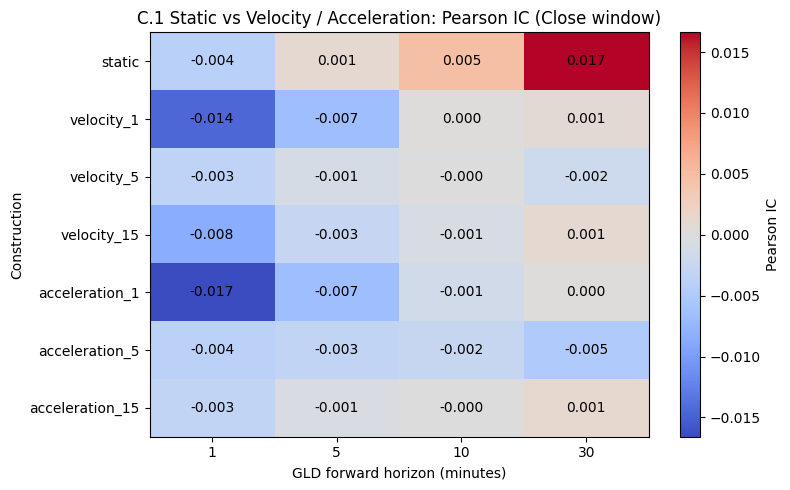

In [10]:
plt.figure(figsize=(8, 5))
plt.imshow(c1_ic_matrix.values, aspect="auto", cmap="coolwarm")
plt.colorbar(label="Pearson IC")
plt.xticks(range(len(c1_ic_matrix.columns)), c1_ic_matrix.columns)
plt.yticks(range(len(c1_ic_matrix.index)), c1_ic_matrix.index)
plt.xlabel("GLD forward horizon (minutes)")
plt.ylabel("Construction")
plt.title("C.1 Static vs Velocity / Acceleration: Pearson IC (Close window)")
for i in range(c1_ic_matrix.shape[0]):
    for j in range(c1_ic_matrix.shape[1]):
        value = c1_ic_matrix.iloc[i, j]
        if pd.notna(value):
            plt.text(j, i, f"{value:.3f}", ha="center", va="center")
plt.tight_layout()
plt.show()


#### C.1 top-two selection


,construction,spec_label,spec_slug,signal_col,horizon,pearson_ic,spearman_ic,n_obs
0,static,static,static,surge_static,30,0.016617,-0.000850,14609
1,static,static,static,surge_static,10,0.004750,0.004275,14651


=== C1_static_h30 continuous diagnostics ===


,candidate,construction,horizon,pearson_ic,spearman_ic,avg_bps,hit_rate,sharpe,sortino,n_obs,n_days
0,C1_static_h30,static,30,0.016617,-0.00085,0.593722,0.500787,0.699926,1.155564,14609,246


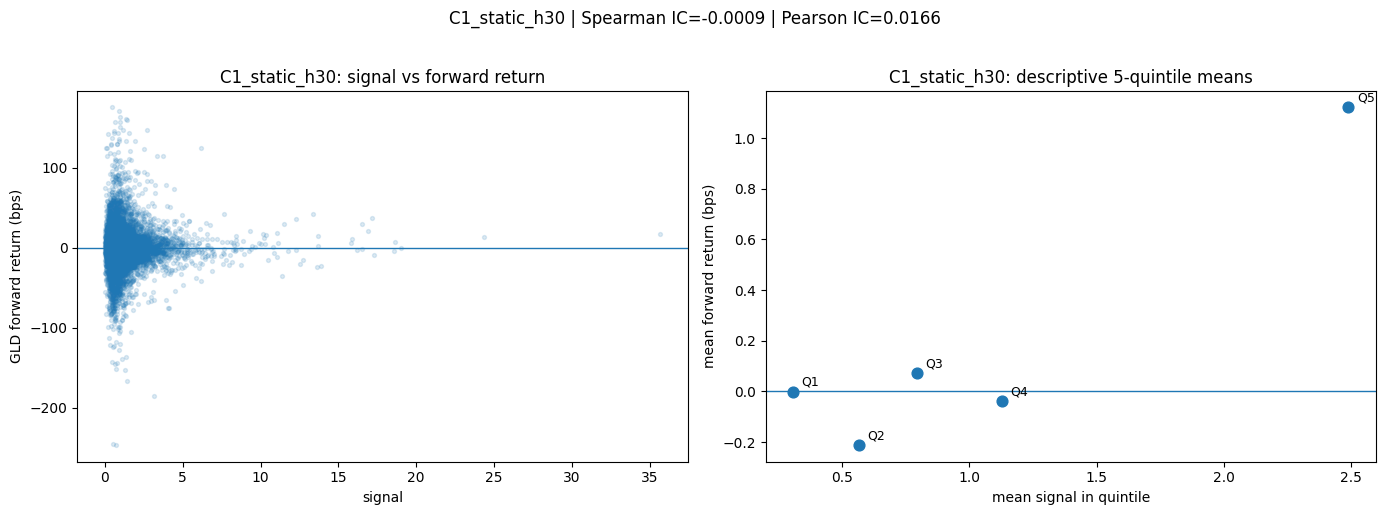

,plot_quintile,mean_signal,mean_fwd_bps,n
0,Q1,0.306711,-0.000163,2922
1,Q2,0.563290,-0.210544,2922
2,Q3,0.794376,0.072188,2921
3,Q4,1.126442,-0.036384,2922
4,Q5,2.491887,1.120609,2922


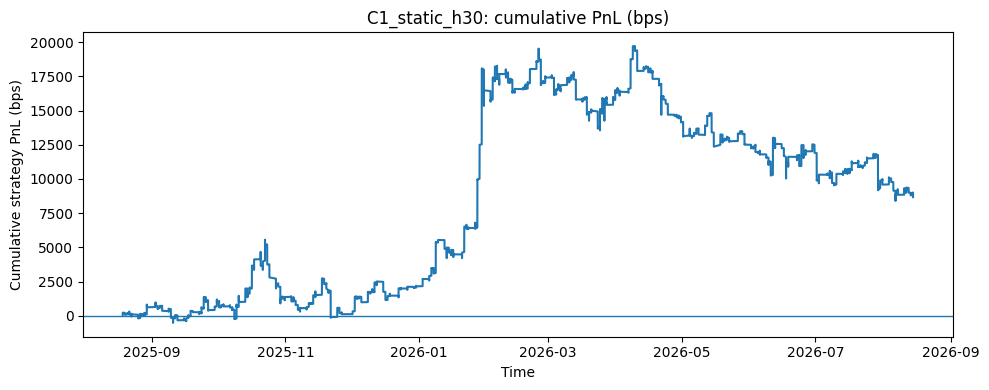

=== C1_static_h10 continuous diagnostics ===


,candidate,construction,horizon,pearson_ic,spearman_ic,avg_bps,hit_rate,sharpe,sortino,n_obs,n_days
0,C1_static_h10,static,10,0.00475,0.004275,0.10987,0.506723,0.282958,0.37923,14651,246


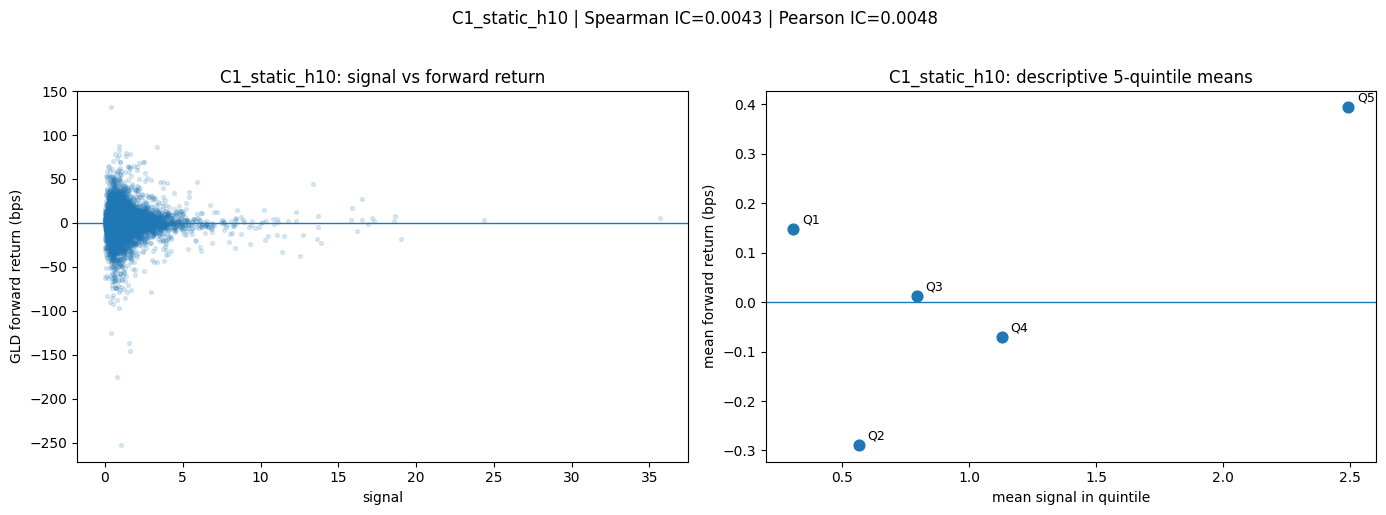

,plot_quintile,mean_signal,mean_fwd_bps,n
0,Q1,0.306973,0.148280,2931
1,Q2,0.563409,-0.288602,2930
2,Q3,0.794695,0.011462,2930
3,Q4,1.127055,-0.070163,2930
4,Q5,2.492429,0.393649,2930


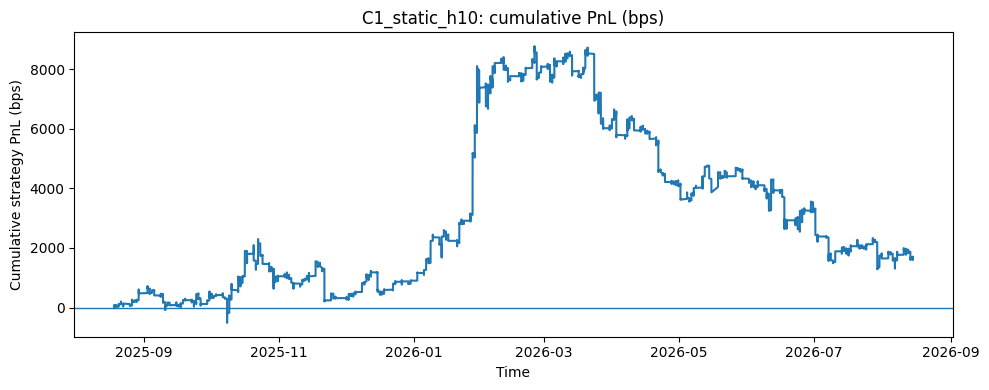

=== C.1 baseline comparison (same horizon) ===


,candidate,horizon,baseline_equivalent,candidate_pearson_ic,candidate_spearman_ic,baseline_pearson_ic,baseline_spearman_ic,pearson_ic_delta,verdict
0,C1_static_h30,30,True,0.016617,-0.000850,0.016617,-0.000850,0.0,baseline-equivalent / tied
1,C1_static_h10,10,True,0.004750,0.004275,0.004750,0.004275,0.0,baseline-equivalent / tied


In [11]:
c1_top_two = rank_top_two(c1_results)
display(c1_top_two)

c1_metric_rows = []
c1_compare_rows = []

for _, row in c1_top_two.iterrows():
    cid = f"C1_{row['spec_slug']}_h{int(row['horizon'])}"
    signal_col = row["signal_col"]
    horizon = int(row["horizon"])
    baseline_equivalent = (row["spec_label"] == "static")

    sample = horizon_specific_sample(signal_col, horizon)
    ic = compute_close_ic(signal_col, horizon)
    strategy = continuous_strategy_frame(sample)

    metrics = {
        "candidate": cid,
        "construction": row["spec_label"],
        "horizon": horizon,
        "pearson_ic": ic["pearson_ic"],
        "spearman_ic": ic["spearman_ic"],
        **summarize_strategy_returns(strategy),
    }
    c1_metric_rows.append(metrics)
    print(f"=== {cid} continuous diagnostics ===")
    display(pd.DataFrame([metrics]))
    plot_candidate_diagnostics(cid, sample, strategy)

    c1_compare_rows.append(
        baseline_comparison_row(
            cid, signal_col, horizon, baseline_equivalent=baseline_equivalent
        )
    )

c1_compare = pd.DataFrame(c1_compare_rows)
print("=== C.1 baseline comparison (same horizon) ===")
display(c1_compare)


#### C.1 assessment

**Signal screen:** Static baseline surge dominates. At 30m, static Pearson IC = 0.016617; the next-best non-static cells (acceleration_15 / velocity_15) are only ~0.001. Several short-horizon velocity/acceleration ICs are negative (e.g. velocity_1 / acceleration_1 at 1m) - that is a weak or cooling relationship, not an automatic upgrade over static.

**Within-subsection ranking:** Top two cells by signed Pearson are both static: 30m (0.016617) and 10m (0.004750). No velocity/acceleration cell enters the top two.

**Baseline comparison:** Both retained cells are baseline-equivalent / tied by construction (same static signal).

**Decision:** Velocity/acceleration do not improve on static surge in this one-axis continuous screen. Continuous diagnostics use signal * forward_return only (no q80). In-sample research screen only.


#### C.2 Duration / Persistence Above Elevated Threshold

This is an **event-based** subsection.

**Local q80 only:** “Elevated” means the baseline static surge signal is above its **own** lagged historical expanding 80th percentile. This threshold exists here because C.2 explicitly studies duration above an elevated-volume state — it is **not** a global strategy rule for C.1 / D / E.

Threshold is past-only: expanding quantile shifted by one.

Streak / burst resets when:
- signal falls below threshold
- date changes
- timestamp gap is not exactly 1 minute

Confirmation durations tested: **1, 2, 3, 4**.

**Mathematical definition**

Past-only elevated threshold on baseline static $S$:

$$
Q_t = \mathrm{Quantile}_{0.80}\!\left(\{S_s\}_{s<t}\right)
\quad(\texttt{expanding(min\_periods=50)}.\texttt{quantile(0.80)}.\texttt{shift(1)})
$$

$$
E_t = \mathbf{1}\{S_t > Q_t\}
$$

Let $N_t$ be the consecutive elevated-bar streak (resets when $E_t=0$, the date changes, or the timestamp gap is not exactly 1 minute).

Confirmation-$N$ entry (one per burst):

$$
\mathrm{Entry}_t^{(N)} = \mathbf{1}\{N_t = N\},\qquad N \in \{1,2,3,4\}
$$

(Not $\mathbf{1}\{N_t \ge N\}$.)

Event evaluation (Close window): mean of $R_{t,t+h}$ in bps, hit rate, and eligible event count — not continuous IC.

Interpretation: **enter when the streak FIRST reaches N** (one entry per burst per confirmation rule). Example elevated burst 15:21–15:25 → N=1 at 15:21, N=2 at 15:22, N=3 at 15:23, N=4 at 15:24.

Do **not** treat every row with streak ≥ N as another entry.

Event metrics: mean forward return bps, hit rate, eligible event count. No continuous IC / signal-weighted package forced onto this discrete event question.


In [12]:
# C.2 local elevated threshold (past-only expanding q80 of baseline static signal)
surge_thresh = (
    data[BASELINE_SIGNAL_COL]
    .expanding(min_periods=50)
    .quantile(0.80)
    .shift(1)
)
elevated = data[BASELINE_SIGNAL_COL] > surge_thresh

# Causal streak with date / gap resets
streak = np.full(len(data), np.nan)
run = 0
prev_time = None
prev_date = None

times = data["Time"].to_numpy()
dates = data["date"].to_numpy()
above_vals = elevated.to_numpy()
thresh_ok = surge_thresh.notna().to_numpy()

for i in range(len(data)):
    t = times[i]
    d = dates[i]

    if prev_time is not None:
        same_date = d == prev_date
        gap_ok = (pd.Timestamp(t) - pd.Timestamp(prev_time)) == pd.Timedelta(minutes=1)
        if not (same_date and gap_ok):
            run = 0

    if thresh_ok[i] and bool(above_vals[i]):
        run += 1
        streak[i] = run
    elif not thresh_ok[i]:
        run = 0
        streak[i] = np.nan
    else:
        run = 0
        streak[i] = 0.0

    prev_time = t
    prev_date = d

data["surge_thresh"] = surge_thresh
data["surge_above"] = elevated.astype(float).where(surge_thresh.notna())
data["surge_streak"] = streak

# One entry per burst when streak FIRST reaches N  <=>  streak == N
for n in [1, 2, 3, 4]:
    data[f"c2_entry_n{n}"] = (data["surge_streak"] == n).astype(float)

print("elevated close-session bars:", int(((data["surge_above"] == 1) &
    (data["Time"].dt.time >= CLOSE_START) &
    (data["Time"].dt.time < CLOSE_END)).sum()))
print("max streak (all rows):", np.nanmax(streak))


elevated close-session bars: 3181
max streak (all rows): 18.0


In [13]:
close_mask = (
    (data["Time"].dt.time >= CLOSE_START) &
    (data["Time"].dt.time < CLOSE_END)
)

c2_results = []
for n in [1, 2, 3, 4]:
    entry_mask = data[f"c2_entry_n{n}"] == 1
    for h in HORIZONS:
        vals = data.loc[close_mask & entry_mask, f"GLD_fwd_{h}m_bps"].dropna()
        c2_results.append({
            "duration": n,
            "spec_label": f"confirm_{n}",
            "spec_slug": f"n{n}",
            "horizon": h,
            "mean_fwd_bps": vals.mean() if len(vals) else np.nan,
            "hit_rate": (vals > 0).mean() if len(vals) else np.nan,
            "n_events": len(vals),
        })

c2_results = pd.DataFrame(c2_results)
c2_mean_matrix = c2_results.pivot(
    index="duration", columns="horizon", values="mean_fwd_bps"
)
c2_count_matrix = c2_results.pivot(
    index="duration", columns="horizon", values="n_events"
)
c2_hit_matrix = c2_results.pivot(
    index="duration", columns="horizon", values="hit_rate"
)

display(c2_results.sort_values(
    ["mean_fwd_bps", "hit_rate", "n_events", "spec_label", "horizon"],
    ascending=[False, False, False, True, True],
))
print("mean fwd bps")
display(c2_mean_matrix)
print("hit rate")
display(c2_hit_matrix)
print("event counts")
display(c2_count_matrix)


,duration,spec_label,spec_slug,horizon,mean_fwd_bps,hit_rate,n_events
15,4,confirm_4,n4,30,3.936949,0.573643,129
13,4,confirm_4,n4,5,1.846551,0.538462,130
14,4,confirm_4,n4,10,1.519091,0.538462,130
11,3,confirm_3,n3,30,1.234782,0.519856,277
7,2,confirm_2,n2,30,1.155570,0.514683,647
3,1,confirm_1,n1,30,0.620319,0.487462,1994
12,4,confirm_4,n4,1,0.476118,0.530769,130
6,2,confirm_2,n2,10,0.370837,0.540000,650
10,3,confirm_3,n3,10,0.247992,0.526882,279
9,3,confirm_3,n3,5,0.174656,0.526882,279


mean fwd bps


horizon,1,5,10,30
duration,,,,
1,0.089104,-0.095030,0.155839,0.620319
2,-0.058352,0.060580,0.370837,1.155570
3,0.132717,0.174656,0.247992,1.234782
4,0.476118,1.846551,1.519091,3.936949


hit rate


horizon,1,5,10,30
duration,,,,
1,0.516484,0.503497,0.501249,0.487462
2,0.503077,0.523077,0.540000,0.514683
3,0.508961,0.526882,0.526882,0.519856
4,0.530769,0.538462,0.538462,0.573643


event counts


horizon,1,5,10,30
duration,,,,
1,2002,2002,2001,1994
2,650,650,650,647
3,279,279,279,277
4,130,130,130,129


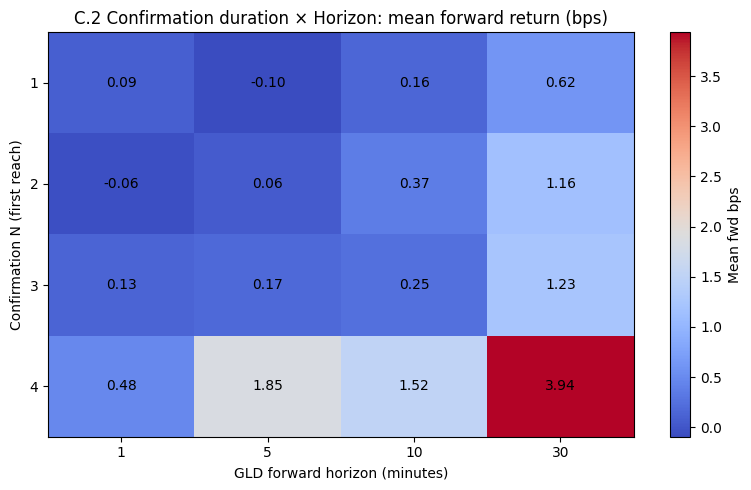

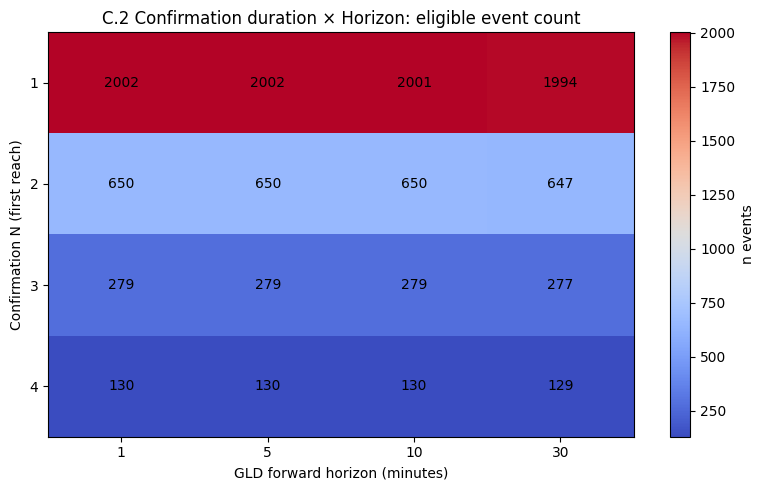

In [14]:
plt.figure(figsize=(8, 5))
plt.imshow(c2_mean_matrix.values, aspect="auto", cmap="coolwarm")
plt.colorbar(label="Mean fwd bps")
plt.xticks(range(len(c2_mean_matrix.columns)), c2_mean_matrix.columns)
plt.yticks(range(len(c2_mean_matrix.index)), c2_mean_matrix.index)
plt.xlabel("GLD forward horizon (minutes)")
plt.ylabel("Confirmation N (first reach)")
plt.title("C.2 Confirmation duration × Horizon: mean forward return (bps)")
for i in range(c2_mean_matrix.shape[0]):
    for j in range(c2_mean_matrix.shape[1]):
        value = c2_mean_matrix.iloc[i, j]
        if pd.notna(value):
            plt.text(j, i, f"{value:.2f}", ha="center", va="center")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.imshow(c2_count_matrix.values, aspect="auto", cmap="coolwarm")
plt.colorbar(label="n events")
plt.xticks(range(len(c2_count_matrix.columns)), c2_count_matrix.columns)
plt.yticks(range(len(c2_count_matrix.index)), c2_count_matrix.index)
plt.xlabel("GLD forward horizon (minutes)")
plt.ylabel("Confirmation N (first reach)")
plt.title("C.2 Confirmation duration × Horizon: eligible event count")
for i in range(c2_count_matrix.shape[0]):
    for j in range(c2_count_matrix.shape[1]):
        value = c2_count_matrix.iloc[i, j]
        if pd.notna(value):
            plt.text(j, i, f"{value:.0f}", ha="center", va="center")
plt.tight_layout()
plt.show()


#### C.2 top-two selection

Ranked by mean forward return (bps) as the primary criterion. Deterministic label/horizon keys break exact ties only — hit rate and event count do not override a non-tied mean-bps difference.


,duration,spec_label,spec_slug,horizon,mean_fwd_bps,hit_rate,n_events
0,4,confirm_4,n4,30,3.936949,0.573643,129
1,4,confirm_4,n4,5,1.846551,0.538462,130


=== C2_confirm4_h30 provisional non-overlapping event diagnostic ===


,candidate,duration,horizon,mean_fwd_bps_events,hit_rate_events,n_events,avg_bps_per_trade,hit_rate,sharpe,sortino,n_trades,n_days
0,C2_confirm4_h30,4,30,3.936949,0.573643,129,4.422007,0.582609,3.426639,9.110155,115,104


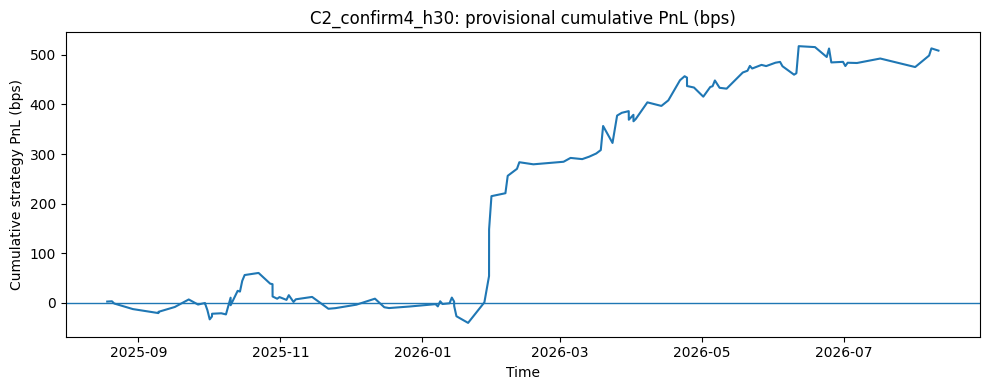

=== C2_confirm4_h5 provisional non-overlapping event diagnostic ===


,candidate,duration,horizon,mean_fwd_bps_events,hit_rate_events,n_events,avg_bps_per_trade,hit_rate,sharpe,sortino,n_trades,n_days
0,C2_confirm4_h5,4,5,1.846551,0.538462,130,1.846551,0.538462,2.812039,5.61483,130,105


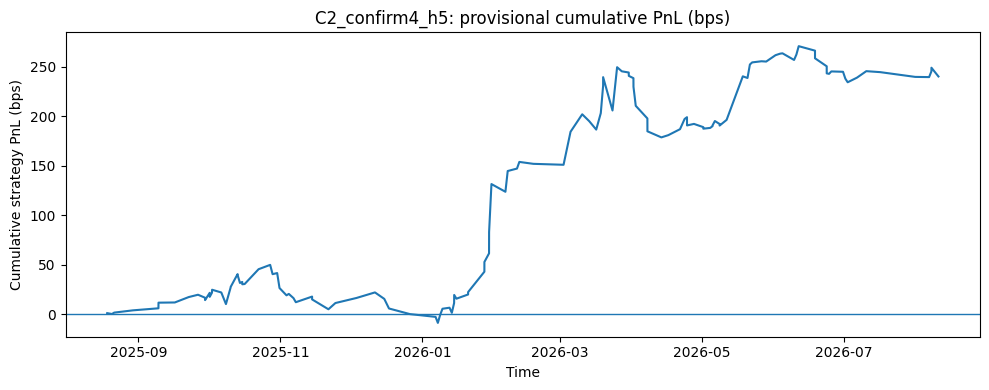

,candidate,duration,horizon,mean_fwd_bps_events,hit_rate_events,n_events,avg_bps_per_trade,hit_rate,sharpe,sortino,n_trades,n_days
0,C2_confirm4_h30,4,30,3.936949,0.573643,129,4.422007,0.582609,3.426639,9.110155,115,104
1,C2_confirm4_h5,4,5,1.846551,0.538462,130,1.846551,0.538462,2.812039,5.614830,130,105


In [15]:
# Primary: mean forward bps. Hit rate / n_events do not override non-tied mean bps.
# Secondary keys are deterministic tie-breaks only (exact mean_fwd_bps ties).
c2_top_two = (
    c2_results.sort_values(
        ["mean_fwd_bps", "spec_label", "horizon"],
        ascending=[False, True, True],
    )
    .head(2)
    .reset_index(drop=True)
)
display(c2_top_two)

# Provisional non-overlapping long diagnostic on selected event entries (not a continuous IC package)
c2_diag_rows = []
for _, row in c2_top_two.iterrows():
    n = int(row["duration"])
    horizon = int(row["horizon"])
    cid = f"C2_confirm{n}_h{horizon}"
    fwd = f"GLD_fwd_{horizon}m"
    fwd_bps = f"GLD_fwd_{horizon}m_bps"

    sample = data.loc[
        close_mask & (data[f"c2_entry_n{n}"] == 1),
        ["Time", "date", fwd, fwd_bps],
    ].dropna().copy()
    sample = sample.rename(columns={fwd: "fwd_return", fwd_bps: "fwd_return_bps"})
    sample["position"] = 1.0

    trades = build_nonoverlapping_trades(sample, horizon)
    strat = summarize_strategy_returns(trades)
    metrics = {
        "candidate": cid,
        "duration": n,
        "horizon": horizon,
        "mean_fwd_bps_events": row["mean_fwd_bps"],
        "hit_rate_events": row["hit_rate"],
        "n_events": int(row["n_events"]),
        "avg_bps_per_trade": strat["avg_bps"],
        "hit_rate": strat["hit_rate"],
        "sharpe": strat["sharpe"],
        "sortino": strat["sortino"],
        "n_trades": strat["n_obs"],
        "n_days": strat["n_days"],
    }
    c2_diag_rows.append(metrics)
    print(f"=== {cid} provisional non-overlapping event diagnostic ===")
    display(pd.DataFrame([metrics]))
    if len(trades):
        trades = trades.sort_values("Time").copy()
        trades["cum_bps"] = trades["strategy_return_bps"].cumsum()
        plt.figure(figsize=(10, 4))
        plt.plot(trades["Time"], trades["cum_bps"])
        plt.axhline(0, linewidth=1)
        plt.xlabel("Time")
        plt.ylabel("Cumulative strategy PnL (bps)")
        plt.title(f"{cid}: provisional cumulative PnL (bps)")
        plt.tight_layout()
        plt.show()

c2_diag = pd.DataFrame(c2_diag_rows)
display(c2_diag)


#### C.2 assessment

**Event screen:** Ranking uses mean forward bps as primary (deterministic ties only). Confirmation N=4 is strongest: ~3.94 mean bps @ 30m (n=129 events) and ~1.85 mean bps @ 5m (n=130). Event counts fall as N rises — sparsity is expected under one-entry-per-burst.

**Within-subsection ranking:** Top two = confirm_4 @ 30m and confirm_4 @ 5m.

**Interpretation:** Provisional non-overlapping diagnostics are sparse (~115 trades / 104 days at 30m). Results are **provisional** and require robustness / OOS validation. Do not treat in-sample mean bps as settled edge.

**Decision:** Written top-two findings only for Section C synthesis.


#### C.3 Burst Phase

C.3 asks **what phase** the elevated burst is in, not how long it has lasted.

C.2 studies duration / confirmation. C.3 studies phase / state. Related, not duplicates.

Uses the **same local past-only elevated threshold** from C.2 (subsection-specific q80; not global).

**Mathematical definition**

Reuse C.2's past-only $Q_t$, $E_t$, and streak $N_t$. With $S_t$ the baseline static signal:

$$
\mathrm{Onset}_t = \mathbf{1}\{N_t = 1\}
$$

$$
\mathrm{RisingFlank}_t = \mathbf{1}\{E_t=1,\ S_t > S_{t-1},\ N_t \ge 2\}
\quad(\text{excludes onset})
$$

$$
\mathrm{Persistence}_t = \mathbf{1}\{N_t \ge 2\}
$$

$$
\mathrm{ConfirmedFade}_t = \mathbf{1}\{E_t=1,\ S_t < S_{t-1},\ S_{t-1} > S_{t-2}\}
$$

All definitions are causal (no future information). Phases may overlap. Event evaluation: mean $R_{t,t+h}$ bps, hit rate, event count.

Causal phase definitions only (no future information):

- **ONSET:** first elevated minute / streak == 1
- **RISING FLANK:** already elevated and current static signal > previous static signal; **exclude onset**
- **PERSISTENCE:** elevated with streak ≥ 2 (broad state diagnostic)
- **CONFIRMED FADE:** current bar elevated; previous bar was rising relative to its predecessor; current static signal < previous signal

Event metrics: mean forward bps, hit rate, event count. Continuous IC / signal-weighted metrics are not forced here.


In [16]:
# C.3 causal phase flags (reuse C.2 local elevated / streak construction)
s = data[BASELINE_SIGNAL_COL]
rising = s > s.shift(1)
falling = s < s.shift(1)
was_rising = s.shift(1) > s.shift(2)
elevated_flag = data["surge_above"] == 1

data["phase_onset"] = (data["surge_streak"] == 1).astype(float)
data["phase_rising_flank"] = (
    elevated_flag & rising & (data["surge_streak"] >= 2)
).astype(float)
data["phase_persist"] = (data["surge_streak"] >= 2).astype(float)
data["phase_fade"] = (elevated_flag & falling & was_rising).astype(float)

c3_phases = {
    "onset": "phase_onset",
    "rising_flank": "phase_rising_flank",
    "persistence": "phase_persist",
    "confirmed_fade": "phase_fade",
}


In [17]:
c3_results = []
for label, col in c3_phases.items():
    phase_mask = data[col] == 1
    for h in HORIZONS:
        vals = data.loc[close_mask & phase_mask, f"GLD_fwd_{h}m_bps"].dropna()
        c3_results.append({
            "phase": label,
            "spec_label": label,
            "spec_slug": label,
            "horizon": h,
            "mean_fwd_bps": vals.mean() if len(vals) else np.nan,
            "hit_rate": (vals > 0).mean() if len(vals) else np.nan,
            "n_events": len(vals),
        })

c3_results = pd.DataFrame(c3_results)
c3_mean_matrix = c3_results.pivot(
    index="phase", columns="horizon", values="mean_fwd_bps"
).reindex(list(c3_phases.keys()))
c3_count_matrix = c3_results.pivot(
    index="phase", columns="horizon", values="n_events"
).reindex(list(c3_phases.keys()))
c3_hit_matrix = c3_results.pivot(
    index="phase", columns="horizon", values="hit_rate"
).reindex(list(c3_phases.keys()))

display(c3_results.sort_values(
    ["mean_fwd_bps", "hit_rate", "n_events", "spec_label", "horizon"],
    ascending=[False, False, False, True, True],
))
print("mean fwd bps")
display(c3_mean_matrix)
print("hit rate")
display(c3_hit_matrix)
print("event counts")
display(c3_count_matrix)


,phase,spec_label,spec_slug,horizon,mean_fwd_bps,hit_rate,n_events
7,rising_flank,rising_flank,rising_flank,30,1.759631,0.516696,569
11,persistence,persistence,persistence,30,1.678222,0.523444,1173
15,confirmed_fade,confirmed_fade,confirmed_fade,30,0.856066,0.510978,501
10,persistence,persistence,persistence,10,0.695356,0.539440,1179
3,onset,onset,onset,30,0.620319,0.487462,1994
14,confirmed_fade,confirmed_fade,confirmed_fade,10,0.569203,0.544732,503
6,rising_flank,rising_flank,rising_flank,10,0.457096,0.529720,572
9,persistence,persistence,persistence,5,0.407180,0.528414,1179
13,confirmed_fade,confirmed_fade,confirmed_fade,5,0.316142,0.516899,503
12,confirmed_fade,confirmed_fade,confirmed_fade,1,0.224733,0.508946,503


mean fwd bps


horizon,1,5,10,30
phase,,,,
onset,0.089104,-0.095030,0.155839,0.620319
rising_flank,0.014931,0.166241,0.457096,1.759631
persistence,0.192680,0.407180,0.695356,1.678222
confirmed_fade,0.224733,0.316142,0.569203,0.856066


hit rate


horizon,1,5,10,30
phase,,,,
onset,0.516484,0.503497,0.501249,0.487462
rising_flank,0.517483,0.534965,0.529720,0.516696
persistence,0.515691,0.528414,0.539440,0.523444
confirmed_fade,0.508946,0.516899,0.544732,0.510978


event counts


horizon,1,5,10,30
phase,,,,
onset,2002,2002,2001,1994
rising_flank,572,572,572,569
persistence,1179,1179,1179,1173
confirmed_fade,503,503,503,501


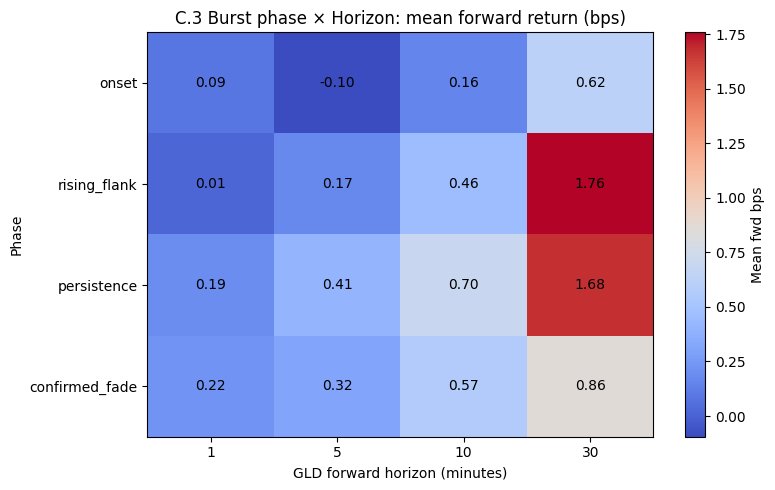

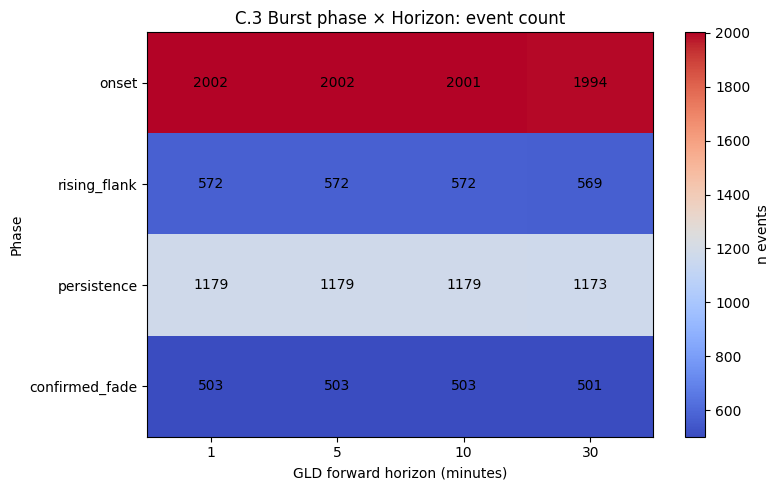

In [18]:
plt.figure(figsize=(8, 5))
plt.imshow(c3_mean_matrix.values, aspect="auto", cmap="coolwarm")
plt.colorbar(label="Mean fwd bps")
plt.xticks(range(len(c3_mean_matrix.columns)), c3_mean_matrix.columns)
plt.yticks(range(len(c3_mean_matrix.index)), c3_mean_matrix.index)
plt.xlabel("GLD forward horizon (minutes)")
plt.ylabel("Phase")
plt.title("C.3 Burst phase × Horizon: mean forward return (bps)")
for i in range(c3_mean_matrix.shape[0]):
    for j in range(c3_mean_matrix.shape[1]):
        value = c3_mean_matrix.iloc[i, j]
        if pd.notna(value):
            plt.text(j, i, f"{value:.2f}", ha="center", va="center")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.imshow(c3_count_matrix.values, aspect="auto", cmap="coolwarm")
plt.colorbar(label="n events")
plt.xticks(range(len(c3_count_matrix.columns)), c3_count_matrix.columns)
plt.yticks(range(len(c3_count_matrix.index)), c3_count_matrix.index)
plt.xlabel("GLD forward horizon (minutes)")
plt.ylabel("Phase")
plt.title("C.3 Burst phase × Horizon: event count")
for i in range(c3_count_matrix.shape[0]):
    for j in range(c3_count_matrix.shape[1]):
        value = c3_count_matrix.iloc[i, j]
        if pd.notna(value):
            plt.text(j, i, f"{value:.0f}", ha="center", va="center")
plt.tight_layout()
plt.show()


#### C.3 top-two selection


In [19]:
c3_top_two = (
    c3_results.sort_values(
        ["mean_fwd_bps", "spec_label", "horizon"],
        ascending=[False, True, True],
    )
    .head(2)
    .reset_index(drop=True)
)
display(c3_top_two)

# Overlap note among phases on the close session
phase_close = data.loc[close_mask, list(c3_phases.values())]
overlap = pd.DataFrame({
    a: {b: int(((phase_close[ca] == 1) & (phase_close[cb] == 1)).sum())
        for b, cb in c3_phases.items()}
    for a, ca in c3_phases.items()
})
print("Close-session phase co-occurrence counts (not mutually exclusive):")
display(overlap)


,phase,spec_label,spec_slug,horizon,mean_fwd_bps,hit_rate,n_events
0,rising_flank,rising_flank,rising_flank,30,1.759631,0.516696,569
1,persistence,persistence,persistence,30,1.678222,0.523444,1173


Close-session phase co-occurrence counts (not mutually exclusive):


,onset,rising_flank,persistence,confirmed_fade
onset,2002,0,0,0
rising_flank,0,572,572,0
persistence,0,572,1179,503
confirmed_fade,0,0,503,503


#### C.3 assessment

**Event screen:** Ranking uses mean forward bps as primary (deterministic ties only). At 30m, rising_flank (~1.76 bps, n=569) and persistence (~1.68 bps, n=1173) lead; onset is weaker. Confirmed fade sits below the top two.

**Overlap:** Phases are not mutually exclusive: rising_flank ⊆ persistence here (572 co-occurrences); fade overlaps persistence (503). Onset is excluded from rising flank by construction. C.2 answers duration/confirmation; C.3 answers phase/state.

**Decision:** Top two = rising_flank @ 30m and persistence @ 30m. Evidence remains provisional.


### Section C - Conclusion

**Question:** Does velocity/acceleration improve on static surge? Is waiting for persistence useful? Does onset / rising / fade matter?

**What each subsection established**
- **C.1 (continuous IC):** No — static remains strongest (top two = static @ 30m / 10m). Vel/acc ICs are near zero or negative.
- **C.2 (event duration):** Waiting for confirmation appears useful in-sample: confirm_4 leads on mean fwd bps, but event counts are sparse and results are provisional.
- **C.3 (event phase):** Rising flank and persistence at 30m lead among phases; onset is weaker. Phases overlap, so treat as related state views, not independent candidates.

**Strongest C findings (written only — no registry DataFrame):**
- Continuous evidence type: static baseline surge.
- Event evidence type: elevated confirmation N=4 and rising/persistence phases at longer horizons — provisional / sparse.

**What remains provisional:** In-sample only. OOS / walk-forward has **not** been completed. No joint C×D testing.


# Section D — Time-of-Day Windows

Section D is a fresh **one-axis** experiment from the **original baseline** (`GC_signal_30`).

Do **not** start from a C winner, B.4 uptick, A.1 lookback winner, or any combined survivor.

Only the time-of-day window varies. Baseline construction otherwise remains fixed.

Jira-defined windows:
- early close: 15:00–15:30
- last half-hour: 15:30–16:00
- full close: 15:00–16:00

Different windows naturally have different `n_obs`. Sample-size difference alone is not a performance advantage or disadvantage.

Continuous diagnostics for selected cells use `strategy_return = signal * forward_return` (no q80 / no binary threshold).


**Mathematical definition**

Section D does **not** create a new volume-surge formula. The underlying signal remains the baseline $S_t$.

Only the time-domain conditioning changes. Half-open windows matching the implementation:

$$
W_{\mathrm{early}} = [15{:}00,\ 15{:}30),\quad
W_{\mathrm{late}} = [15{:}30,\ 16{:}00),\quad
W_{\mathrm{full}} = [15{:}00,\ 16{:}00)
$$

$$
\mathrm{IC}_{W,h} = \mathrm{Corr}\!\left(S_t,\ R_{t,t+h}\ \middle|\ t \in W\right)
$$

for $W \in \{W_{\mathrm{early}}, W_{\mathrm{late}}, W_{\mathrm{full}}\}$ and $h \in \{1,5,10,30\}$.

The signal formula is unchanged; Section D changes the subset of timestamps over which its predictive relationship is evaluated.


In [20]:
d_windows = {
    "early_close": (time(15, 0), time(15, 30)),
    "last_half_hour": (time(15, 30), time(16, 0)),
    "full_close": (time(15, 0), time(16, 0)),
}

d_results = []
for label, (start, end) in d_windows.items():
    for h in HORIZONS:
        stats = compute_close_ic(
            BASELINE_SIGNAL_COL, h, session_start=start, session_end=end
        )
        d_results.append({
            "window": label,
            "spec_label": label,
            "spec_slug": label,
            "session_start": start,
            "session_end": end,
            "horizon": h,
            "pearson_ic": stats["pearson_ic"],
            "spearman_ic": stats["spearman_ic"],
            "n_obs": stats["n_obs"],
        })

d_results = pd.DataFrame(d_results)
d_ic_matrix = d_results.pivot(
    index="window", columns="horizon", values="pearson_ic"
).reindex(list(d_windows.keys()))
d_n_matrix = d_results.pivot(
    index="window", columns="horizon", values="n_obs"
).reindex(list(d_windows.keys()))

display(d_results.sort_values(
    ["pearson_ic", "spearman_ic", "spec_label", "horizon"],
    ascending=[False, False, True, True],
))
display(d_ic_matrix)
display(d_n_matrix)


,window,spec_label,spec_slug,session_start,session_end,horizon,pearson_ic,spearman_ic,n_obs
3,early_close,early_close,early_close,15:00:00,15:30:00,30,0.028412,0.027834,7328
11,full_close,full_close,full_close,15:00:00,16:00:00,30,0.016617,-0.000850,14609
2,early_close,early_close,early_close,15:00:00,15:30:00,10,0.013554,0.024604,7328
1,early_close,early_close,early_close,15:00:00,15:30:00,5,0.013520,0.020864,7328
10,full_close,full_close,full_close,15:00:00,16:00:00,10,0.004750,0.004275,14651
4,last_half_hour,last_half_hour,last_half_hour,15:30:00,16:00:00,1,0.002970,0.000013,7325
7,last_half_hour,last_half_hour,last_half_hour,15:30:00,16:00:00,30,0.001267,-0.030008,7281
9,full_close,full_close,full_close,15:00:00,16:00:00,5,0.000964,0.009340,14653
8,full_close,full_close,full_close,15:00:00,16:00:00,1,-0.003982,0.006929,14653
6,last_half_hour,last_half_hour,last_half_hour,15:30:00,16:00:00,10,-0.006515,-0.020065,7323


horizon,1,5,10,30
window,,,,
early_close,-0.008506,0.013520,0.013554,0.028412
last_half_hour,0.002970,-0.014125,-0.006515,0.001267
full_close,-0.003982,0.000964,0.004750,0.016617


horizon,1,5,10,30
window,,,,
early_close,7328,7328,7328,7328
last_half_hour,7325,7325,7323,7281
full_close,14653,14653,14651,14609


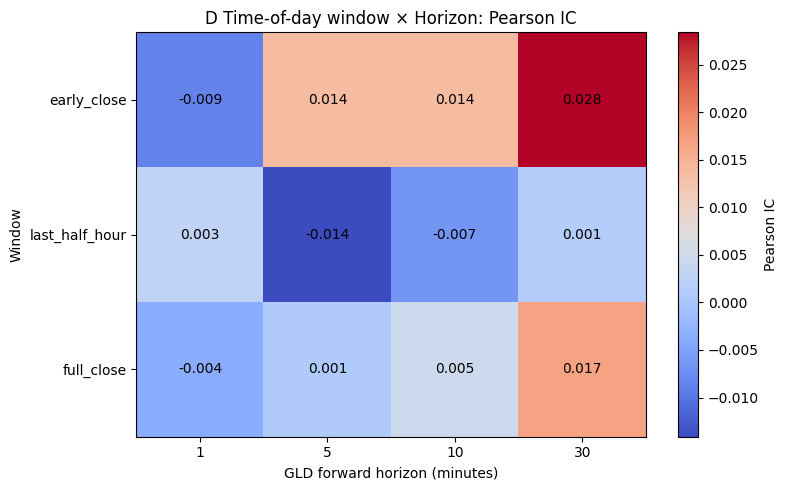

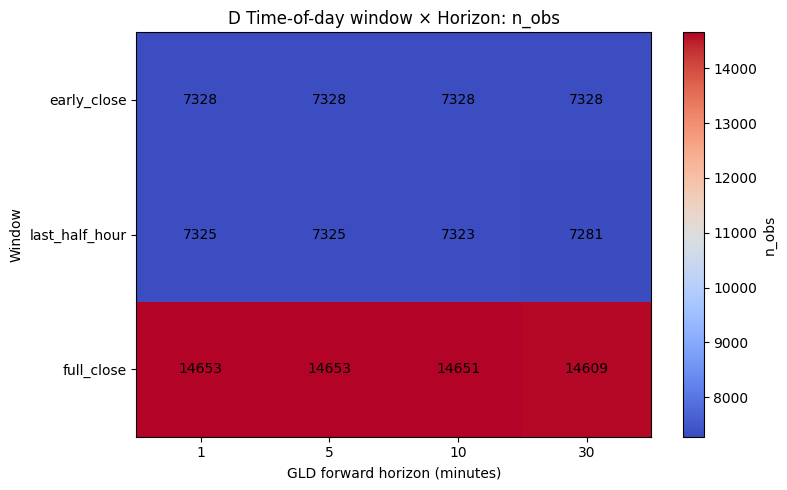

In [21]:
plt.figure(figsize=(8, 5))
plt.imshow(d_ic_matrix.values, aspect="auto", cmap="coolwarm")
plt.colorbar(label="Pearson IC")
plt.xticks(range(len(d_ic_matrix.columns)), d_ic_matrix.columns)
plt.yticks(range(len(d_ic_matrix.index)), d_ic_matrix.index)
plt.xlabel("GLD forward horizon (minutes)")
plt.ylabel("Window")
plt.title("D Time-of-day window × Horizon: Pearson IC")
for i in range(d_ic_matrix.shape[0]):
    for j in range(d_ic_matrix.shape[1]):
        value = d_ic_matrix.iloc[i, j]
        if pd.notna(value):
            plt.text(j, i, f"{value:.3f}", ha="center", va="center")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.imshow(d_n_matrix.values, aspect="auto", cmap="coolwarm")
plt.colorbar(label="n_obs")
plt.xticks(range(len(d_n_matrix.columns)), d_n_matrix.columns)
plt.yticks(range(len(d_n_matrix.index)), d_n_matrix.index)
plt.xlabel("GLD forward horizon (minutes)")
plt.ylabel("Window")
plt.title("D Time-of-day window × Horizon: n_obs")
for i in range(d_n_matrix.shape[0]):
    for j in range(d_n_matrix.shape[1]):
        value = d_n_matrix.iloc[i, j]
        if pd.notna(value):
            plt.text(j, i, f"{value:.0f}", ha="center", va="center")
plt.tight_layout()
plt.show()


#### D top-two selection


,window,spec_label,spec_slug,session_start,session_end,horizon,pearson_ic,spearman_ic,n_obs
0,early_close,early_close,early_close,15:00:00,15:30:00,30,0.028412,0.027834,7328
1,full_close,full_close,full_close,15:00:00,16:00:00,30,0.016617,-0.000850,14609


=== D_early_close_h30 continuous diagnostics ===


,candidate,window,horizon,pearson_ic,spearman_ic,avg_bps,hit_rate,sharpe,sortino,n_obs,n_days
0,D_early_close_h30,early_close,30,0.028412,0.027834,1.046011,0.510508,0.85911,1.329161,7328,246


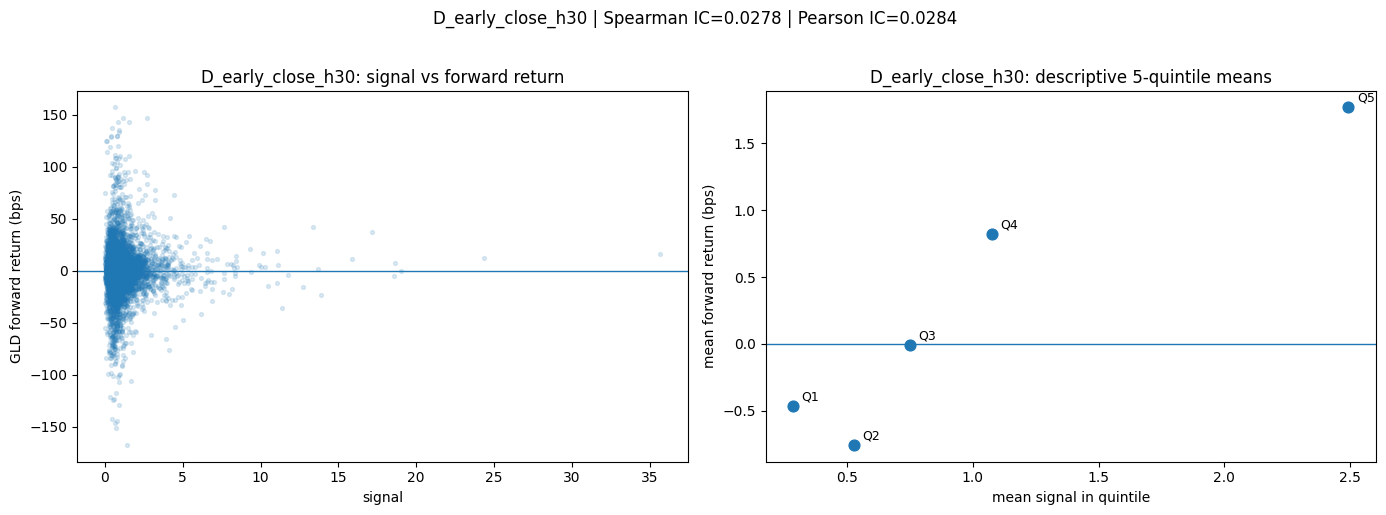

,plot_quintile,mean_signal,mean_fwd_bps,n
0,Q1,0.285604,-0.464241,1466
1,Q2,0.526370,-0.754988,1465
2,Q3,0.748756,-0.005749,1466
3,Q4,1.076998,0.825773,1465
4,Q5,2.494549,1.769615,1466


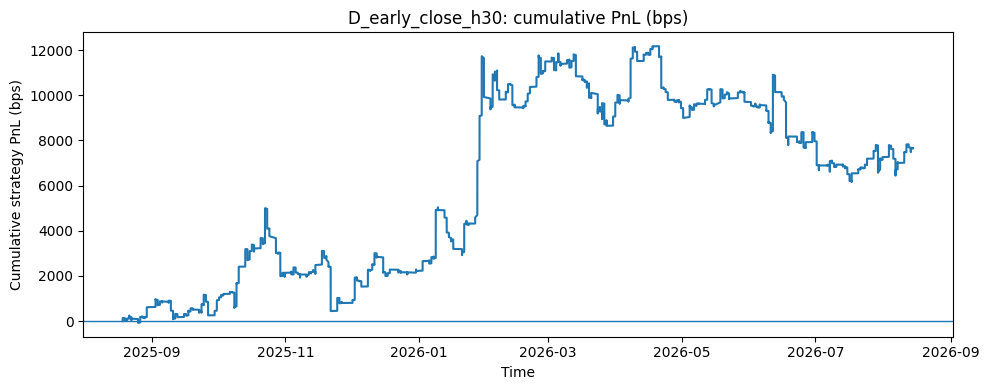

=== D_full_close_h30 continuous diagnostics ===


,candidate,window,horizon,pearson_ic,spearman_ic,avg_bps,hit_rate,sharpe,sortino,n_obs,n_days
0,D_full_close_h30,full_close,30,0.016617,-0.00085,0.593722,0.500787,0.699926,1.155564,14609,246


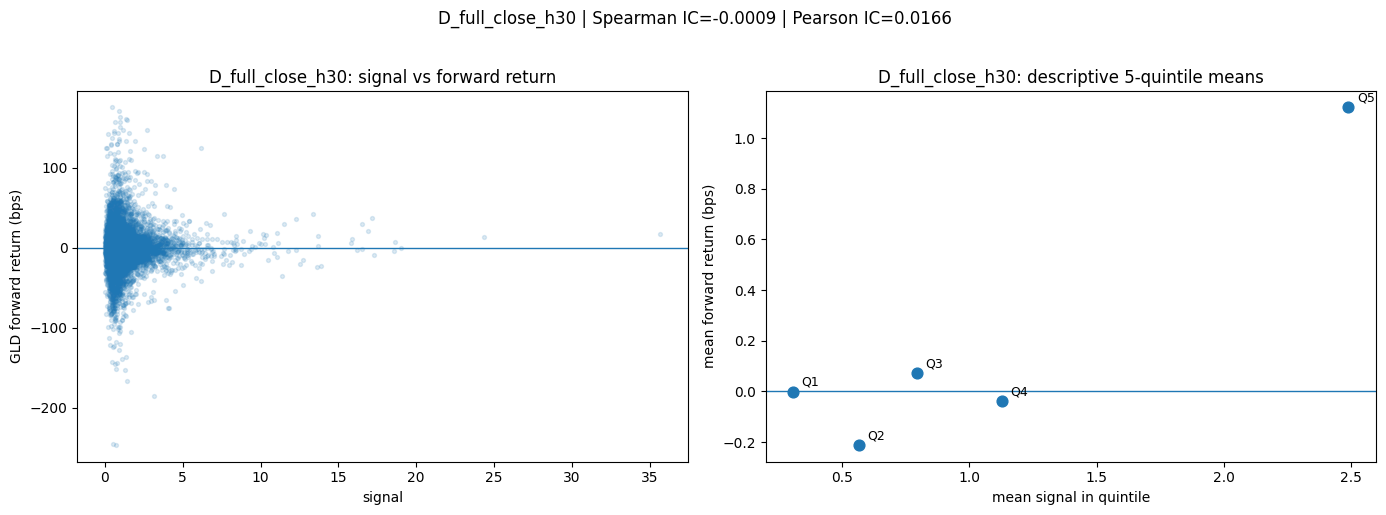

,plot_quintile,mean_signal,mean_fwd_bps,n
0,Q1,0.306711,-0.000163,2922
1,Q2,0.563290,-0.210544,2922
2,Q3,0.794376,0.072188,2921
3,Q4,1.126442,-0.036384,2922
4,Q5,2.491887,1.120609,2922


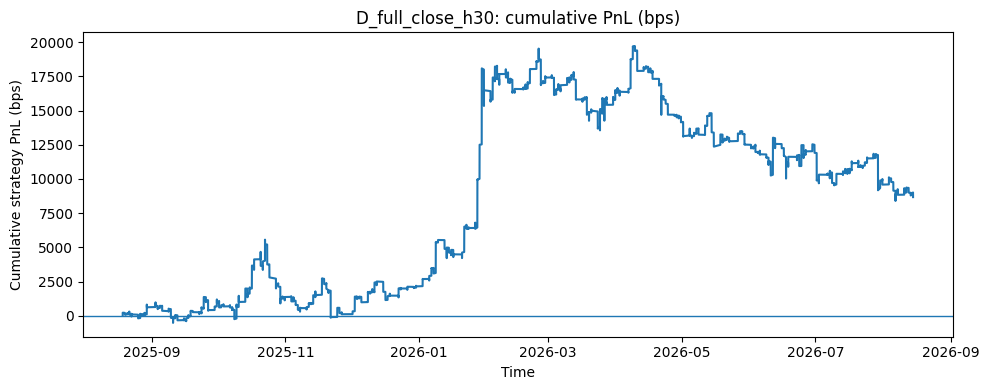

=== D vs full-close control (same horizon; different window samples) ===


,candidate,horizon,baseline_equivalent,candidate_pearson_ic,candidate_spearman_ic,baseline_pearson_ic,baseline_spearman_ic,pearson_ic_delta,verdict
0,D_early_close_h30,30,False,0.028412,0.027834,0.016617,-0.00085,0.011795,higher IC than full-close control
1,D_full_close_h30,30,True,0.016617,-0.000850,0.016617,-0.00085,0.000000,equivalent to full-close control


In [22]:
d_top_two = rank_top_two(d_results)
display(d_top_two)

d_metric_rows = []
d_compare_rows = []

for _, row in d_top_two.iterrows():
    cid = f"D_{row['spec_slug']}_h{int(row['horizon'])}"
    horizon = int(row["horizon"])
    start, end = row["session_start"], row["session_end"]
    baseline_equivalent = (row["spec_label"] == "full_close")

    sample = horizon_specific_sample(
        BASELINE_SIGNAL_COL, horizon, session_start=start, session_end=end
    )
    ic = compute_close_ic(
        BASELINE_SIGNAL_COL, horizon, session_start=start, session_end=end
    )
    strategy = continuous_strategy_frame(sample)

    metrics = {
        "candidate": cid,
        "window": row["spec_label"],
        "horizon": horizon,
        "pearson_ic": ic["pearson_ic"],
        "spearman_ic": ic["spearman_ic"],
        **summarize_strategy_returns(strategy),
    }
    d_metric_rows.append(metrics)
    print(f"=== {cid} continuous diagnostics ===")
    display(pd.DataFrame([metrics]))
    plot_candidate_diagnostics(cid, sample, strategy)

    d_compare_rows.append(
        baseline_comparison_row(
            cid,
            BASELINE_SIGNAL_COL,
            horizon,
            baseline_equivalent=baseline_equivalent,
            session_start=start,
            session_end=end,
        )
    )

d_compare = pd.DataFrame(d_compare_rows)
# Different windows use different timestamp samples — not a same-sample "beat".
_verdict_map = {
    "candidate beats baseline": "higher IC than full-close control",
    "baseline beats candidate": "lower IC than full-close control",
    "baseline-equivalent / tied": "equivalent to full-close control",
}
d_compare["verdict"] = d_compare["verdict"].map(_verdict_map).fillna(d_compare["verdict"])
print("=== D vs full-close control (same horizon; different window samples) ===")
display(d_compare)


#### Manager question: last half-hour vs full close

Does the baseline surge result concentrate in the first half of the close hour, the last half-hour, or the full close?

**Answer from D results:** At 5m / 10m / 30m, **early close (15:00–15:30)** leads on signed Pearson IC (30m: 0.0284 vs full close 0.0166 vs last half-hour 0.0013). Last half-hour is not where the useful-horizon association concentrates. Full close averages the stronger early half with a weaker late half. `n_obs` is roughly half in each half-hour window by construction — that alone is not a performance argument.


In [23]:
# Explicit concentration summary for the manager question
d_focus = d_results.pivot(
    index="window", columns="horizon", values="pearson_ic"
).reindex(["early_close", "last_half_hour", "full_close"])
print("Pearson IC by window × horizon:")
display(d_focus)

best_by_horizon = (
    d_results.sort_values(["horizon", "pearson_ic"], ascending=[True, False])
    .groupby("horizon", as_index=False)
    .first()[["horizon", "window", "pearson_ic", "n_obs"]]
)
print("Strongest window at each horizon (by signed Pearson):")
display(best_by_horizon)


Pearson IC by window × horizon:


horizon,1,5,10,30
window,,,,
early_close,-0.008506,0.013520,0.013554,0.028412
last_half_hour,0.002970,-0.014125,-0.006515,0.001267
full_close,-0.003982,0.000964,0.004750,0.016617


Strongest window at each horizon (by signed Pearson):


,horizon,window,pearson_ic,n_obs
0,1,last_half_hour,0.002970,7325
1,5,early_close,0.013520,7328
2,10,early_close,0.013554,7328
3,30,early_close,0.028412,7328


#### D assessment

**Signal screen:** Only the session window varies; signal = inherited baseline.

**Within-subsection ranking:** Top two = early_close @ 30m (Pearson 0.0284, n=7328) and full_close @ 30m (0.0166, n=14609).

**Baseline / control comparison:** early_close @ 30m shows a higher IC than the full-close control (delta ~0.012; different timestamp samples). full_close @ 30m is equivalent to the full-close control.

**Manager answer:** Useful-horizon association concentrates in the **first half** of the close hour, not the last half-hour.

**Decision:** Written top-two findings only. No joint C×D testing. No C/D registry.


### Section D - Conclusion

**Question:** Does the baseline volume-surge association concentrate in early close, last half-hour, or full close?

**Takeaway:** In-sample, the stronger association is in **early close (15:00–15:30)**, especially at 30m. Last half-hour is weak at useful horizons; full close sits between them. This remains a one-axis research screen — OOS is not claimed.


### Open robustness item (not solved in C/D)

C.2 / C.3 provide persistence / phase evidence for elevated **baseline static** surge, but they do **not** fully answer the manager’s “same burst counted 10 times” concern for the **B.4 uptick @ 1m** candidate.

**Open robustness item:** B.4 uptick @ 1m must still be retested using one entry per independent burst to determine how much of the minute-level result comes from repeated observations within the same burst.

This note does not silently change generic / global helpers.


### Validation status

C/D remain **research screens**. Out-of-sample / walk-forward testing has **not** been completed. No fake train/test split is added for appearance. OOS remains an explicit later validation item.


# Section E — GC vs MGC Lead/Lag and Differences

This is the next continuation section.


### Remaining helper inventory

| Helper | Why it remains |
|---|---|
| `horizon_specific_sample` | Canonical horizon-specific session sample (optional window for D) |
| `compute_close_ic` | Shared Pearson + Spearman IC on that sample |
| `rank_top_two` | Consistent signed-Pearson top-two for continuous screens |
| `continuous_strategy_frame` | Continuous `strategy_return = signal * forward_return` |
| `summarize_strategy_returns` | Continuous avg_bps / hit / Sharpe / Sortino / n_obs / n_days from strategy-return series |
| `build_nonoverlapping_trades` | Provisional non-overlapping trades for explicit event entries (C.2) |
| `baseline_comparison_verdict` | Same-horizon tolerance-aware verdict labels |
| `baseline_comparison_row` | Short IC-only comparison vs full-close control |
| `plot_candidate_diagnostics` | Scatter + quintile (+ cum PnL when strategy series exists) |
